In [114]:
import findspark
findspark.init()
import sys

In [115]:
### Data Engineering Assessments starts here

In [116]:
def load_data(spark, read_path):
    "Data Munging: Raw Data Discovery"
    '''
    The source CSV contained embedded commas and line breaks within quoted text fields (e.g., job descriptions). 
    To prevent incorrect parsing and column misalignment, multiline parsing with quote and escape handling was enabled.
    '''
    df=spark.read\
        .option("header", "true")\
        .option("inferSchema","false")\
        .option("quote",'"')\
        .option("multiline","true")\
        .option("escape",'"')\
        .csv(read_path)
    
# Clean column names to remove leading/trailing whitespace and
# Windows carriage return characters (\r) that may cause schema mismatches in Linux environments

    df = df.toDF(*[c.strip().replace("\r", "") for c in df.columns])
    
    df.printSchema()
    return df

In [117]:
def data_cleaning(df):
    "Data Preparation"
    '''
    Data Exploration was performed on raw data to understand structure and quality. Data Processing steps were derived 
    from exploration insights to ensure informed transformations.
    '''
    total_rows = df.count()  # 2946
    print("Total rows : ", total_rows)
    "Null Counts"
    null_counts = df.select([
        sum(when(col(c).isNull() | (col(c) == ''),1).otherwise(0)).alias(c)
        for c in df.columns])

    rows=null_counts.first().asDict()
    cols_with_nulls = [k for k, v in rows.items() if v > 0]
    nulls_threshold = [k for k,v in rows.items() if (v/total_rows) > 0.3]

    print("Columns with NULL values:")
    print(cols_with_nulls)

    print("\nColumns with NULL threshold > 30%:")
    print(nulls_threshold)

    '''
    NULL values in textual columns (e.g., Preferred Skills, Minimum Qual Requirements) were preserved due to lack of 
    business rules for imputation and to avoid loss of information.
    '''
    "As we are tokenizing the preferred skills in the down lets replace null values with spaces as tokenizer can't accept NULLS"
    df = df.withColumn(
        "preferred_skills_clean",
        F.coalesce(F.col("Preferred Skills"), F.lit(""))
    )
    return df

In [118]:
def data_pre_processing(df):
    "Data Wrangling"
    '''While exploring the dataset, I observed the presence of unwanted Unicode/encoding artifacts (e.g., special bullet symbols 
    and mis-encoded characters such as Ã¢â‚¬Â¢) in the Preferred Skills column. These characters likely originated from encoding 
    inconsistencies during CSV ingestion.
    As part of the data cleaning process, I applied a regular expression transformation to remove non-alphanumeric characters 
    before performing text analysis. This ensures consistent tokenization and accurate skill extraction.'''

    # Convert to lowercase for uniform processing
    '''To preserve raw data integrity, transformations were applied to a new derived column (preferred_skills_clean) 
    rather than modifying the original field.'''

    df = df.withColumn("preferred_skills_clean",F.lower(F.col("preferred_skills_clean")))
    # Remove non-alphanumeric characters (including encoding artifacts)
    df = df.withColumn("preferred_skills_clean",F.regexp_replace("preferred_skills_clean", "[^a-z0-9 ]", " "))

    "Column profiling -- Distinct counts helped identify categorical vs high-cardinality columns"

    print("\nColumns with their Distinct counts:")
    df.select([
        countDistinct(col(c)).alias(c) for c in df.columns]
    ).show(truncate=False)

    "With the above we can understand the low cardinal columns - categorical columns etc and high cardinal columns - IDs, descriptions etc"
    "Data Preparation: Data Cleaning"

    "Data Enrichment - casting"
    # Cast numeric columns
    df = df.withColumn("# Of Positions",col("# Of Positions").cast("int"))\
        .withColumn("Salary Range From", col("Salary Range From").cast("double"))\
        .withColumn("Salary Range To", col("Salary Range To").cast("double"))
    
    #Data Cleaning
    df = df.filter(col("Salary Range From").isNotNull() & (col("Salary Range From") > 0))\
        .filter(col("Salary Range To").isNotNull() & (col("Salary Range To") > 0))
 
    # Convert date columns
    fmt = "yyyy-MM-dd'T'HH:mm:ss.SSS"
    df = df.withColumn(
        "Post Until",
        when(col("Post Until") == "", None).otherwise(col("Post Until"))
    )
    
    df = df.withColumn("Posting Date", to_timestamp("Posting Date", fmt)) \
           .withColumn("Post Until", to_timestamp("Post Until", fmt)) \
           .withColumn("Posting Updated", to_timestamp("Posting Updated", fmt)) \
           .withColumn("Process Date", to_timestamp("Process Date", fmt))
    
    df = df.withColumn("Posting Date", to_date("Posting Date")) \
           .withColumn("Post Until", to_date("Post Until")) \
           .withColumn("Posting Updated", to_date("Posting Updated")) \
           .withColumn("Process Date", to_date("Process Date"))

    df.printSchema()
    '''Date columns stored as ISO timestamp strings were converted to timestamp and then to date type to ensure accurate parsing " \
    while preserving NULL values.'''

    "Summary statistics for numeric columns"
    print("\nSummary statistics for numeric columns")
    df.describe().select("Summary","Salary Range From", "Salary Range To").show()

    "Top values in categorical columns"
    print("\nTop values in categorical columns:")
    df.groupBy("Job Category").count().orderBy("count", ascending= False).show(10, False)

    return df

In [119]:
def data_normalization(df):
    "Data processing and transformation"
    print("\nQuestion 1: Whats the number of jobs posting per category (Top 10)?")

    top_10_jobs_cnt_per_category = df.groupBy("Job Category").agg(F.count("*").alias("Number of Jobs")).orderBy(col("Number of Jobs").desc()).limit(10)
    top_10_jobs_cnt_per_category.show(10,False)

    
    
    print("\nQuestion 2:Whats the salary distribution per job category?")

    '''Typical assumptions :
    Hourly → 2080 hours/year (40 hrs/week * 52 weeks)
    Daily  → 260 days/year (5 days/week * 52 weeks)
    Annual → same
    '''

    "Salary ranges were first normalized to annual compensation using Salary Frequency to ensure fair comparison across agencies."

    df = df.withColumn("Annual_sal_from",when(col("Salary Frequency") == "Annual", col("Salary Range From"))
                                .when(col("Salary Frequency") == "Daily", col("Salary Range From") * 5 * 52)
                                .when(col("Salary Frequency") == "Hourly", col("Salary Range From") * 40 * 52)
                                .otherwise(None)).\
        withColumn("Annual_sal_to",when(col("Salary Frequency") == "Annual", col("Salary Range To"))
                                .when(col("Salary Frequency") == "Daily", col("Salary Range To") * 5 * 52)
                                .when(col("Salary Frequency") == "Hourly", col("Salary Range To") * 40 * 52)
                                .otherwise(None))

    "Salary midpoint used as average salary for the job, as it better represents typical compensation than the upper bound alone."
    df = df.withColumn("Salary_Mid", (col("Annual_sal_from") + col("Annual_sal_to"))/2)
    df.cache() # cache the dataframe from here we are going to do major transformation
    df = df.withColumn("Job_Category_Array", F.split(col("Job Category"), ",\\s*"))
    df = df.withColumn("Job_Category_Exploded", F.explode("Job_Category_Array"))
    sal_dist_per_cat = df.groupBy("Job_Category_Exploded")\
        .agg(
            F.min("Salary_Mid").alias("min_salary"),
            F.max("Salary_Mid").alias("max_salary"),
            F.avg("Salary_Mid").alias("avg_salary")
    )
    sal_dist_per_cat.show(10, False)
    
    

    print("\nQuestion 3: Is there any correlation between the higher degree and the salary?")

    '''Since the dataset does not contain a structured degree column, I would extract degree requirements from the Minimum 
    Qual Requirements text using keyword matching or regex. Then encode degree levels numerically to compute correlation 
    with salary. we are checking highest degree first to avoid picking High School if a posting contains both
    bachelor and High school'''

    df = df.withColumn("qualification_text", lower(col("Minimum Qual Requirements")))
    df = df.withColumn(
        "Min_Degree",
        when(col("qualification_text").contains("master"), "Master")
        .when(col("qualification_text").contains("baccalaureate") |
              col("qualification_text").contains("bachelor"), "Bachelor")
        .when(col("qualification_text").contains("associate degree"), "Associate")
        .when(col("qualification_text").contains("high school"), "High School")
        .otherwise("Not Specified")
    )
    df.groupBy("Min_Degree").count().show()
    '''
    Since degree level is an ordinal categorical variable, applying direct numerical correlation may introduce artificial 
    spacing assumptions between levels. Therefore, instead of computing correlation, salaries were compared across degree 
    groups to identify trends between education level and compensation.
    '''

    df_corr=df.groupBy("Min_Degree").agg(F.avg("Salary_Mid").alias("avg_sal_mid")).orderBy(F.col("avg_sal_mid").desc())
    df_corr.show()

    '''
    The analysis shows a general upward trend in average salary with increasing degree requirements, indicating a positive relationship 
    between higher education and compensation.
    '''
    

    print("\nQuestion 4: Whats the job posting having the highest salary per agency?")

    w=Window.partitionBy("Agency").orderBy(col("Salary_Mid").desc())
    highest_sal_per_agency=df.withColumn("rw",F.row_number().over(w)).filter(col("rw") == 1).drop("rw").select("Agency","Business Title","Salary_Mid")
    highest_sal_per_agency.show(10, False)

    print("\nQuestion 5: Whats the job positings average salary per agency for the last 2 years?")

    '''The dataset contains historical data (up to 2019). Therefore, the last 2 years were calculated relative to the maximum 
    posting date in the dataset rather than the system date.'''
    Max_Posting_Date = df.agg(F.max("Posting Date")).first()[0]
    filtered_df = df.where(col("Posting Date") >= F.add_months(F.lit(Max_Posting_Date), -24))

    avg_sal_agency = (
        filtered_df.groupBy("Agency")
        .agg(F.avg("Salary_Mid").alias("avg_salary_last_2yrs"))
        .orderBy(F.col("avg_salary_last_2yrs").desc())
    )
    avg_sal_agency.show(truncate=False)

    print("\nQuestion 6: What are the highest paid skills in the US market?")

    '''Since skills were provided as unstructured text, I performed text normalization and tokenization on the Preferred Skills 
    column, removed noise terms, and computed word frequencies. I then associated average salary with each skill keyword to 
    identify the highest paid skills.'''

    # Create tokenizer object to the cleaned skills columns to get array of words
    tokenizer= Tokenizer(inputCol="preferred_skills_clean", outputCol="words")
    df_tokenized = tokenizer.transform(df)
    #df_tokenized.show(10, False)
    #Built in stopwords remover
    default_stopwords = StopWordsRemover.loadDefaultStopWords("english")
    '''Based on frequency analysis of tokenized text, additional domain-specific stopwords were identified and removed
    to eliminate generic job-description terms. This improved the accuracy of skill extraction before computing average
    salary per skill.'''
    custom_stopwords = ["experience","skills","skill","ability","knowledge",
    "strong","excellent","work","working","years","year","preferred","including",
    "written","communication","management","new","required","must","state","time",
    "detail","using","wide","organizational","verbal","interpersonal","proficiency",
    "multiple","public","project","projects","systems","system","office","city",
    "word","york","data","candidate","candidates","demonstrated","related","plus",
    "analytical","team","oral","well","familiarity","development","technical",
    "improvement","success","goals","continuous","managerial","leading","leader",
    "implement","overseeing","environment"]
    all_stopwords = default_stopwords + custom_stopwords
    remover= StopWordsRemover(inputCol="words", outputCol="filtered_words", stopWords=all_stopwords)
    df_filtered=remover.transform(df_tokenized)
    #df_filtered.show(10, False)
    #Explode filtered words into rows
    tech_skills = [
        "python", "sql", "aws", "azure", "spark",
        "excel", "powerbi", "tableau",
        "kubernetes", "docker",
        "devops", "linux", "java",
        "cloud", "security"
    ]
    ngram = NGram(n=2, inputCol="filtered_words", outputCol="bigrams")
    df_ngram = ngram.transform(df_filtered)
    df_exploded=df_filtered.select("Salary_Mid", F.explode("filtered_words").alias("word")).\
    filter(
        (F.col("word").isNotNull()) &
        (F.col("word") != "") &
        (F.length("word") > 2) &
        (~F.col("word").rlike("^[0-9]+$"))
    )
    df_exploded = df_exploded.filter(
        F.col("word").isin(tech_skills)
    )
    #get the high paid skill from the skillset we have
    #df_exploded.groupBy("word").count().orderBy(F.desc("count")).show(20)
    high_paid_skills = (
        df_exploded
            .groupBy("word")
            .agg(
                F.count("*").alias("job_count"),
                F.avg("Salary_Mid").alias("avg_salary")
            )
            .where(F.col("job_count") >= 30)
            .orderBy(F.desc("avg_salary"))
    )

    '''Job descriptions contain significant generic language.
    After applying standard and domain-specific stopword removal, we restricted analysis to a curated list of technical skills 
    to avoid noise from soft skills and HR terminology.This produced more meaningful salary insights aligned with market demand.'''
    # Show top highest paid skills
    high_paid_skills.show(20, False)
    return df,avg_sal_agency, high_paid_skills


In [120]:
def data_write(spark,df,write_path):
    
    final_df = df.select(
        "Job ID",
        "Agency",
        "Business Title",
        "Job Category",
        "Job_Category_Exploded",
        "Salary_Mid",
        "Min_Degree",
        "Posting Date",
        "preferred_skills_clean",
        "Salary Frequency"
    )
    
    # Rename columns to remove spaces (required for Parquet)
    final_df = final_df.toDF(*[
        c.strip()
         .replace(" ", "_")
         .replace("/", "_")
         .replace("#", "No")
        for c in final_df.columns
    ])
    #print("Rows before write:", final_df.count())
    #final_df.show(5)
    final_df.write.mode("overwrite").parquet(write_path + "/processed_nyc_jobs_parquet")

    final_df.coalesce(1).write \
        .mode("overwrite") \
        .option("header", "true") \
        .option("quote", '"') \
        .option("escape", '"') \
        .option("multiLine", "true") \
        .csv(write_path + "/processed_nyc_jobs_csv")
    print("Writing to:", write_path + "/processed_nyc_jobs_parquet")
    print(f"Final dataframe written successfully to {write_path}")
    return final_df

In [121]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F, Window
from pyspark.sql.functions import col, sum, when, countDistinct, to_timestamp, to_date, add_months, lower
from pyspark.ml.feature import StopWordsRemover, Tokenizer, NGram

In [122]:
spark = SparkSession.builder.appName("assessments").getOrCreate()
sc = spark.sparkContext
print("Set the logger level to error")
sc.setLogLevel("ERROR")

Set the logger level to error


In [123]:
print("Get the base location as parameter (to make the code to run in windows/Linux) \n")
read_path = "/dataset/nyc-jobs.csv"
write_path = "/dataset/output"
print("Here read file location is : " + read_path)
print("Here write file location is : " + write_path)

df_raw = load_data(spark, read_path)
df_clean = data_cleaning(df_raw)
df_processed = data_pre_processing(df_clean)
df_final, avg_sal_agency, high_paid_skills = data_normalization(df_processed)
final_df=data_write(spark,df_final,write_path)
#print("Rows after write:", final_df.count())
#final_df.show(5)

#The final dataset was designed as an analysis-ready layer containing all fields required for downstream reporting and 
#visualization across the six business questions.



Get the base location as parameter (to make the code to run in windows/Linux) 

Here read file location is : /dataset/nyc-jobs.csv
Here write file location is : /dataset/output
root
 |-- Job ID: string (nullable = true)
 |-- Agency: string (nullable = true)
 |-- Posting Type: string (nullable = true)
 |-- # Of Positions: string (nullable = true)
 |-- Business Title: string (nullable = true)
 |-- Civil Service Title: string (nullable = true)
 |-- Title Code No: string (nullable = true)
 |-- Level: string (nullable = true)
 |-- Job Category: string (nullable = true)
 |-- Full-Time/Part-Time indicator: string (nullable = true)
 |-- Salary Range From: string (nullable = true)
 |-- Salary Range To: string (nullable = true)
 |-- Salary Frequency: string (nullable = true)
 |-- Work Location: string (nullable = true)
 |-- Division/Work Unit: string (nullable = true)
 |-- Job Description: string (nullable = true)
 |-- Minimum Qual Requirements: string (nullable = true)
 |-- Preferred Skills: st

In [ ]:
### Read back the output file and visualize

In [125]:

import os
print("Current working dir:", os.getcwd())
print("Write path:", write_path)

os.listdir("/dataset/output/processed_nyc_jobs_parquet")


df_output = spark.read.parquet("/dataset/output/processed_nyc_jobs_parquet")
#df_output.show(2, False)


Current working dir: /notebook
Write path: /dataset/output


In [ ]:
### Data Visualization

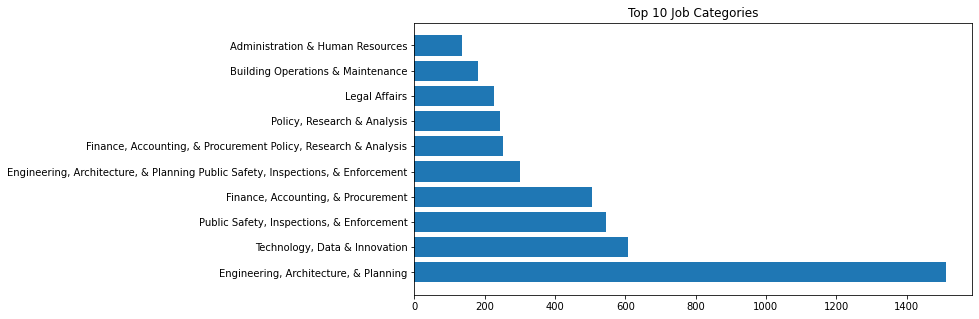

In [126]:
#Q1 — Jobs per Category

import matplotlib.pyplot as plt

top_10_jobs_cnt_per_category = df_output.groupBy("Job_Category") \
    .count() \
    .withColumnRenamed("count", "Number_of_Jobs") \
    .orderBy("count", ascending=False) \
    .limit(10)

pdf = top_10_jobs_cnt_per_category.toPandas()

plt.figure(figsize=(10,5))
plt.barh(pdf["Job_Category"], pdf["Number_of_Jobs"])
plt.title("Top 10 Job Categories")
plt.show()

#The chart shows which job categories have the most openings. The top categories clearly have much higher postings than others,
#which means companies are hiring more in those areas.

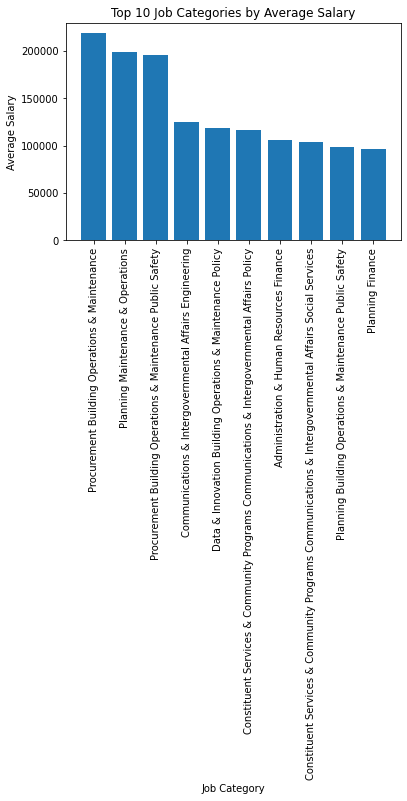

In [109]:
##Q2 — Salary distribution per job category

from pyspark.sql.functions import regexp_replace, trim

df_output = df_output.withColumn(
    "Job_Category_Exploded",
    trim(regexp_replace("Job_Category_Exploded", r"^&\s*", ""))
)

sal_dist_per_cat = df_output.groupBy("Job_Category_Exploded")\
        .agg(
            F.min("Salary_Mid").alias("min_salary"),
            F.max("Salary_Mid").alias("max_salary"),
            F.avg("Salary_Mid").alias("avg_salary")
    )

pdf_q2 = sal_dist_per_cat.orderBy(F.desc("avg_salary")).limit(10).toPandas()

plt.figure()
plt.bar(pdf_q2["Job_Category_Exploded"], pdf_q2["avg_salary"])
plt.xticks(rotation=90)
plt.xlabel("Job Category")
plt.ylabel("Average Salary")
plt.title("Top 10 Job Categories by Average Salary")
plt.show()

#Salaries are different across job categories. Some categories offer much higher average pay,
#which may be because they require special skills or experience.

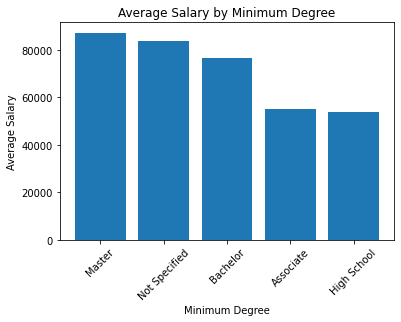

In [110]:
### Q3— Degree vs Salary correlation
df_corr=df_output.groupBy("Min_Degree").agg(F.avg("Salary_Mid").alias("avg_sal_mid")).orderBy(F.col("avg_sal_mid").desc())
pdf_q3 = df_corr.toPandas()

plt.figure()
plt.bar(pdf_q3["Min_Degree"], pdf_q3["avg_sal_mid"])
plt.xticks(rotation=45)
plt.xlabel("Minimum Degree")
plt.ylabel("Average Salary")
plt.title("Average Salary by Minimum Degree")
plt.show()

#Jobs that require higher degrees generally show higher salaries. 

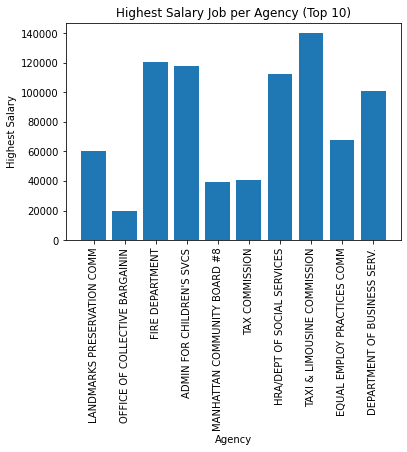

In [111]:
### Q4- Highest salary job per agency

w=Window.partitionBy("Agency").orderBy(col("Salary_Mid").desc())
highest_sal_per_agency=df_output.withColumn("rw",F.row_number().over(w)).filter(col("rw") == 1).drop("rw").select("Agency","Business_Title","Salary_Mid")
highest_sal_per_agency = highest_sal_per_agency.withColumn(
    "Salary_Mid",
    F.col("Salary_Mid").cast("double")
)
pdf_q4 = highest_sal_per_agency.limit(10).toPandas()

plt.figure()
plt.bar(pdf_q4["Agency"], pdf_q4["Salary_Mid"])
plt.xticks(rotation=90)
plt.xlabel("Agency")
plt.ylabel("Highest Salary")
plt.title("Highest Salary Job per Agency (Top 10)")
plt.show()
    
#Each agency has at least one job with a high salary. Some agencies offer much higher maximum salaries than others, 
#possibly for senior or specialized roles.    

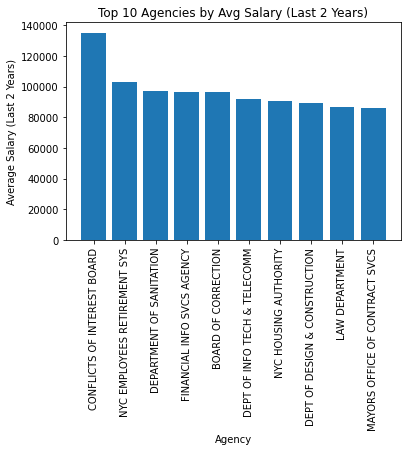

In [112]:
###Q5- Avg salary per agency (last 2 years)

import matplotlib.pyplot as plt

pdf_q5 = avg_sal_agency.limit(10).toPandas()

plt.figure()
plt.bar(pdf_q5["Agency"], pdf_q5["avg_salary_last_2yrs"])
plt.xticks(rotation=90)
plt.xlabel("Agency")
plt.ylabel("Average Salary (Last 2 Years)")
plt.title("Top 10 Agencies by Avg Salary (Last 2 Years)")
plt.show()

#In the last two years, some agencies have offered higher average salaries than others. This may mean they are hiring 
#for higher-level positions or increasing pay to attract talent.

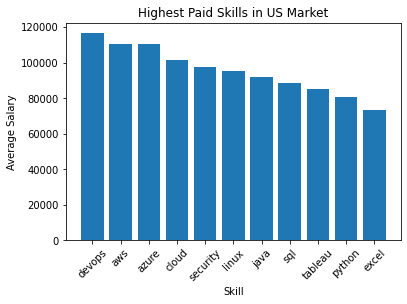

In [113]:
### Q6 — Highest paid skills
import matplotlib.pyplot as plt

# Convert Spark DF to Pandas
pdf = high_paid_skills.toPandas()

plt.figure()
plt.bar(pdf["word"], pdf["avg_salary"])
plt.xticks(rotation=45)
plt.xlabel("Skill")
plt.ylabel("Average Salary")
plt.title("Highest Paid Skills in US Market")
plt.show()

#The chart shows which skills are linked to higher salaries. These skills are likely in high demand, and people 
#who have them may earn more.
